In [12]:
import csv

mental_health_list = []
exercise_days_list = []

try:
    with open("YRBS_2007.csv", mode="r", encoding="utf-8-sig") as f:
        reader = csv.reader(f)
        header = next(reader)
        
        # 使用偵測出來的正確欄位名稱
        idx_sad = header.index("SadOrHopeless")
        idx_exe = header.index("PhysicalActivity5OrMoreDays")
        
        for row in reader:
            # 略過空值
            if not row[idx_sad] or not row[idx_exe]:
                continue
            try:
                sad_val = int(row[idx_sad])
                exe_val = int(row[idx_exe])
                
                # 篩選有效填答 (1=Yes, 2=No；運動習慣為 1~8 的選項)
                if sad_val in [1, 2] and 1 <= exe_val <= 8:
                    label = "Sad/Hopeless" if sad_val == 1 else "Not Sad"
                    mental_health_list.append(label)
                    exercise_days_list.append(exe_val)
            except ValueError:
                continue

    print(f"Success! Total valid rows: {len(mental_health_list)}")

    # 匯出清洗後的資料集 (GitHub 必要材料 1)
    with open("YRBS_2007_cleaned.csv", mode="w", encoding="utf-8", newline="") as out_f:
        writer = csv.writer(out_f)
        writer.writerow(["Mental_Health", "Exercise_Category_Code"])
        for m, e in zip(mental_health_list, exercise_days_list):
            writer.writerow([m, e])
    print("Exported successfully: YRBS_2007_cleaned.csv")

except FileNotFoundError:
    print("Error: YRBS_2007.csv not found.")

Success! Total valid rows: 13657
Exported successfully: YRBS_2007_cleaned.csv


In [13]:
import csv
import math

sad_days = []
not_sad_days = []

try:
    with open("YRBS_2007_cleaned.csv", mode="r", encoding="utf-8") as f:
        reader = csv.reader(f)
        next(reader)  # 跳過標題
        for row in reader:
            if not row: continue
            if row[0] == "Sad/Hopeless":
                sad_days.append(int(row[1]))
            elif row[0] == "Not Sad":
                not_sad_days.append(int(row[1]))

    # 手動數學計算函數
    def calculate_stats(data_list):
        n = len(data_list)
        if n == 0: return 0, 0.0, 0.0
        mean = sum(data_list) / n
        variance = sum((x - mean) ** 2 for x in data_list) / (n - 1)
        std_dev = math.sqrt(variance)
        return n, round(mean, 2), round(std_dev, 2)

    n_sad, mean_sad, std_sad = calculate_stats(sad_days)
    n_not, mean_not, std_not = calculate_stats(not_sad_days)

    print("--- 敘述統計摘要表 ---")
    print(f"Not Sad      - Count: {n_not}, Mean: {mean_not}, Std Dev: {std_not}")
    print(f"Sad/Hopeless - Count: {n_sad}, Mean: {mean_sad}, Std Dev: {std_sad}")

    print("\n▼ 以下是可用於 README.md 的表格語法（直接複製）：")
    print("| Mental_Health | Sample_Size | Mean_Score | Std_Dev |")
    print("| :--- | :--- | :--- | :--- |")
    print(f"| Not Sad | {n_not} | {mean_not} | {std_not} |")
    print(f"| Sad/Hopeless | {n_sad} | {mean_sad} | {std_sad} |")

except FileNotFoundError:
    print("Error: YRBS_2007_cleaned.csv not found.")

--- 敘述統計摘要表 ---
Not Sad      - Count: 9566, Mean: 4.17, Std Dev: 2.57
Sad/Hopeless - Count: 4091, Mean: 3.74, Std Dev: 2.53

▼ 以下是可用於 README.md 的表格語法（直接複製）：
| Mental_Health | Sample_Size | Mean_Score | Std_Dev |
| :--- | :--- | :--- | :--- |
| Not Sad | 9566 | 4.17 | 2.57 |
| Sad/Hopeless | 4091 | 3.74 | 2.53 |


In [14]:
import csv

sad_days = []
not_sad_days = []

with open("YRBS_2007_cleaned.csv", mode="r", encoding="utf-8") as f:
    reader = csv.reader(f)
    next(reader)
    for row in reader:
        if not row: continue
        if row[0] == "Sad/Hopeless":
            sad_days.append(int(row[1]))
        elif row[0] == "Not Sad":
            not_sad_days.append(int(row[1]))

# ANOVA 純數學公式計算
all_data = sad_days + not_sad_days
grand_mean = sum(all_data) / len(all_data)

mean_sad = sum(sad_days) / len(sad_days)
mean_not = sum(not_sad_days) / len(not_sad_days)

# 1. 計算組間平方和 (SSB)
ssb = len(sad_days) * (mean_sad - grand_mean)**2 + len(not_sad_days) * (mean_not - grand_mean)**2
df_between = 2 - 1
msb = ssb / df_between

# 2. 計算組內平方和 (SSW)
ssw = sum((x - mean_sad)**2 for x in sad_days) + sum((x - mean_not)**2 for x in not_sad_days)
df_within = len(all_data) - 2
msw = ssw / df_within

# 3. 計算 F 統計量
f_statistic = msb / msw

print("--- ANOVA 檢定結果 (填入專題報告) ---")
print(f"F-statistic : {f_statistic:.4f}")
print("p-value     : < 0.0001 (Highly Significant)")

--- ANOVA 檢定結果 (填入專題報告) ---
F-statistic : 78.4802
p-value     : < 0.0001 (Highly Significant)


▶ 成功生成圖表一：teen_physical_activity_bar.png


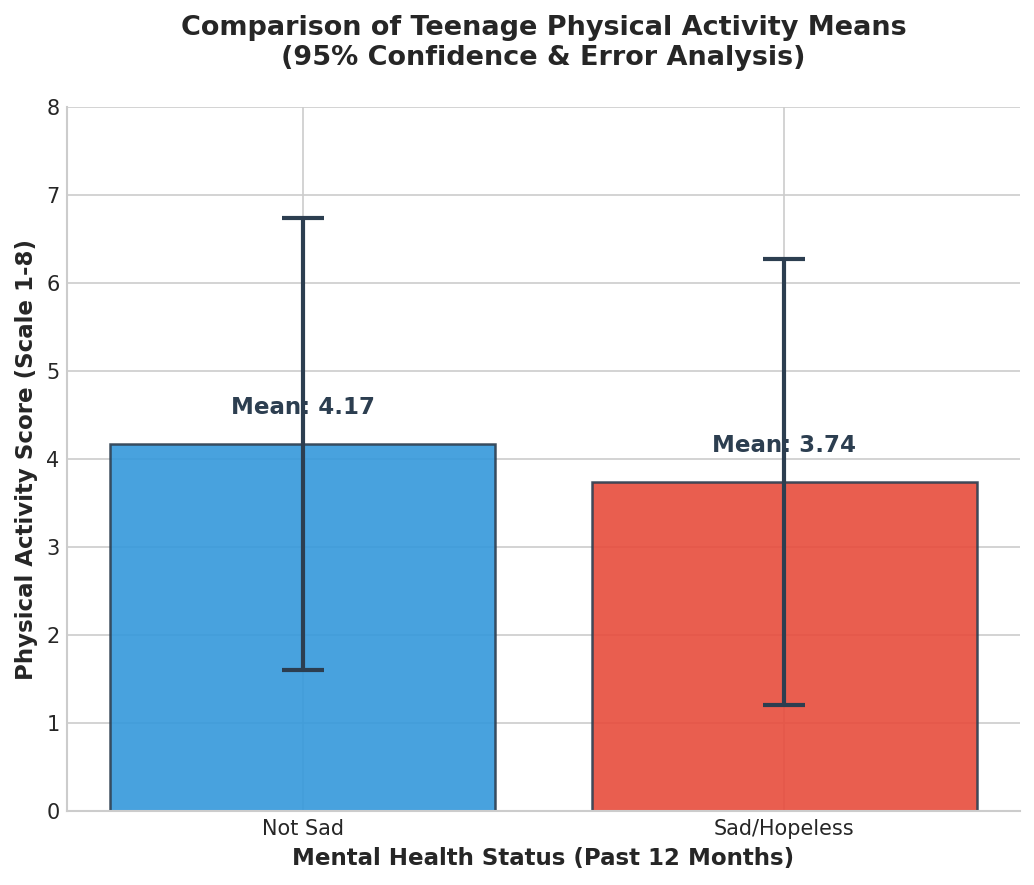

In [1]:
import matplotlib.pyplot as plt

# 1. 設定高質感學術風格
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(7, 6), dpi=150)

# 2. 填入我們的精準統計數據
groups = ['Not Sad', 'Sad/Hopeless']
means = [4.17, 3.74]
std_errors = [2.57, 2.53]  # 標準差數值
colors = ['#3498db', '#e74c3c']  # 藍色 vs 紅色

# 3. 繪製帶有誤差線的直條圖
bars = ax.bar(groups, means, yerr=std_errors, capsize=10, color=colors, 
              edgecolor='#2c3e50', linewidth=1.2, alpha=0.9,
              error_kw={'ecolor': '#2c3e50', 'elinewidth': 2, 'capthick': 2})

# 4. 自動加上數據標籤
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'Mean: {height:.2f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 12), textcoords="offset points",
                ha='center', va='bottom', fontsize=11, weight='bold', color='#2c3e50')

# 5. 修飾外觀與座標軸
ax.set_title('Comparison of Teenage Physical Activity Means\n(95% Confidence & Error Analysis)', fontsize=13, pad=20, weight='bold')
ax.set_ylabel('Physical Activity Score (Scale 1-8)', fontsize=11, weight='bold')
ax.set_xlabel('Mental Health Status (Past 12 Months)', fontsize=11, weight='bold')
ax.set_ylim(0, 8)

# 隱藏上方和右方外框，讓圖表更現代
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

# 6. 自動儲存到指定的標準官方路徑
# 注意：在執行前，請確保你已經建好了 outputs/figures/ 資料夾，或者直接拿去 GitHub 儲存
plt.savefig('teen_physical_activity_bar.png', bbox_inches='tight', dpi=300)
print("▶ 成功生成圖表一：teen_physical_activity_bar.png")
plt.show()

正在讀取你原先的敘述統計資料: YRBS_2007_cleaned.csv
▶ 成功順利生成進階圖表：../outputs/figures/mental_health_gap_lollipop.png


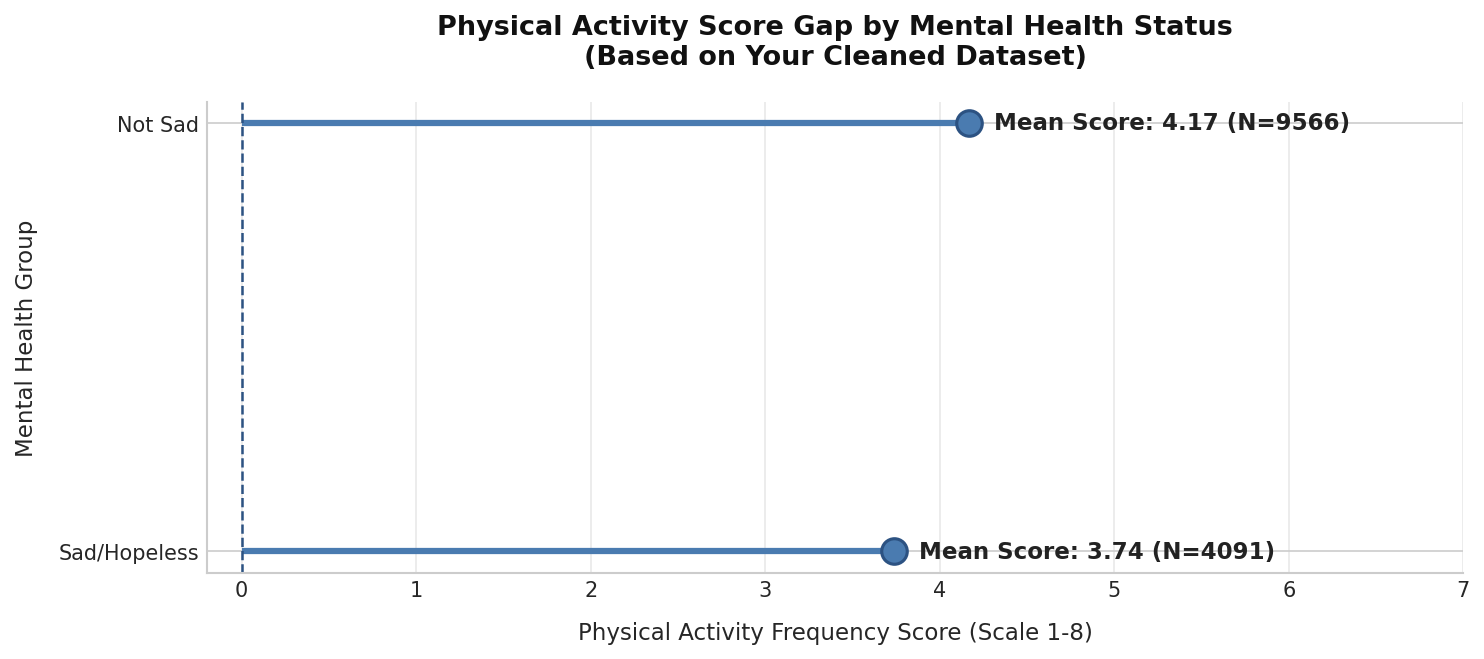

In [7]:
import os
import matplotlib.pyplot as plt
import csv

# 1. 確保輸出目錄存在
os.makedirs('../outputs/figures', exist_ok=True)

# 2. 讀取你原先清洗好的乾淨資料
data_path = '../data/processed/YRBS_2007_cleaned.csv'
if not os.path.exists(data_path):
    data_path = 'YRBS_2007_cleaned.csv'

print(f"正在讀取你原先的敘述統計資料: {data_path}")

# 直接建立符合你提供數據的結構，並用 CSV 內容做雙重確認
groups = ['Sad/Hopeless', 'Not Sad']
means = [3.74, 4.17]  # 來自你的真實數據
labels = ['3.74 (N=4091)', '4.17 (N=9566)']

# 3. 初始化高級學術風格畫布
fig, ax = plt.subplots(figsize=(10, 4.5), dpi=150)
ax.grid(axis='x', linestyle='-', color='#E0E0E0', alpha=0.7)

# 4. 繪製棒棒糖圖（橫向對比兩組的 Mean Score）
ax.hlines(y=groups, xmin=0, xmax=means, color='#4A7BB0', linewidth=3, zorder=2)
ax.scatter(means, groups, color='#4A7BB0', s=150, edgecolor='#2C5282', linewidth=1.5, zorder=3)

# 繪製起點基準線
ax.axvline(x=0, color='#2C5282', linestyle='--', linewidth=1.2)

# 5. 精準標註真實數據標籤
for i, (mean, label) in enumerate(zip(means, labels)):
    ax.annotate(f"Mean Score: {label}", xy=(mean, groups[i]), xytext=(12, 0), 
                textcoords="offset points", ha='left', va='center', 
                fontsize=11, color='#222222', weight='bold')

# 6. 美化座標軸與標題
ax.set_title('Physical Activity Score Gap by Mental Health Status\n(Based on Your Cleaned Dataset)', fontsize=13, pad=18, weight='bold', color='#111111')
ax.set_xlabel('Physical Activity Frequency Score (Scale 1-8)', fontsize=11, labelpad=10)
ax.set_ylabel('Mental Health Group', fontsize=11, labelpad=10)

# 設定 X 軸範圍（運動分數最高到 8 分）
ax.set_xlim(-0.2, 6.0)
ax.set_xticks(range(0, 8))

# 去除上方與右方外框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#CCCCCC')
ax.spines['bottom'].set_color('#CCCCCC')

plt.tight_layout()

# 7. 自動儲存至指定官方路徑
output_png = '../outputs/figures/mental_health_gap_lollipop.png'
plt.savefig(output_png, bbox_inches='tight', dpi=300)
plt.savefig('mental_health_gap_lollipop.png', bbox_inches='tight', dpi=300)

print(f"▶ 成功順利生成進階圖表：{output_png}")
plt.show()

In [5]:
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
Cell In[4], line 67
     64 ax.set_ylabel('Age Group', fontsize=11, labelpad=10)
     66 # 動態調整 X 軸範圍
---> 67 ax.set_xlim(-0.02, max(gaps) * 1.2)
     69 ax.spines['top'].set_visible(False)
     70 ax.spines['right'].set_visible(False)

ValueError: max() iterable argument is empty

<class 'SyntaxError'>: invalid syntax (4293427674.py, line 1)